In [ ]:
class LSTM(nn.Module):
  def __init__(self, input_dim, hidden_dim, num_layers, output_dim, num_epochs, n_labels, n_categories, dropout_p=0.3):
    super(LSTM, self).__init__()

    self.train_test_data = None
    self.num_layers = num_layers
    self.lstm_layers = nn.ModuleList()
    self.dropout_layers = nn.ModuleList()
    self.num_epochs = num_epochs
    self.n_labels = n_labels
    self.n_categories = n_categories

    self.criterion = None

    # Tracking metrics
    self.hist_criterion = []
    self.hist_acc = []
    self.hist_f1 = []
    self.hist_precision = []
    self.hist_recall = []


    # Build LSTM layers + Dropout layers
    self.lstm_layers.append(nn.LSTM(input_dim, hidden_dim[0], batch_first=True))
    self.dropout_layers.append(nn.Dropout(p=dropout_p))

    for i in range(1, self.num_layers):
        self.lstm_layers.append(nn.LSTM(hidden_dim[i-1], hidden_dim[i], batch_first=True))
        self.dropout_layers.append(nn.Dropout(p=dropout_p))

    self.fc = nn.Linear(hidden_dim[-1], output_dim)

    #---------------------------------------------------------------------------
    #Add all definitions
    methods = [forward, multi_task_loss, update_metrics, get_pred, show_metrics, visualize_classification_results]

    for method in methods:
      method_name = method.__name__
      setattr(self, method_name, method.__get__(self))


In [ ]:
def forward(self, x):
    out = x
    for lstm, dropout in zip(self.lstm_layers, self.dropout_layers):
        out, _ = lstm(out)
        out = dropout(out)  # Apply Dropout after each LSTM

    out = out[:, -1, :]  # Take the last output
    out = self.fc(out)   # Shape: (batch_size, output_dim = n_labels * n_categories)

    # Split output into n_labels parts (e.g., 3 parts of 7 classes)
    out_split = torch.split(out, self.n_categories, dim=1)  # List of tensors [(batch, 7), (batch, 7), (batch, 7)]

    return out_split  # tuple of outputs per task

In [ ]:
def multi_task_loss(self, outputs, targets):
    """
    Compute average CrossEntropyLoss over multiple outputs.
    - outputs: list of tensors (batch_size, n_categories)
    - targets: tensor (batch_size, n_labels) with class indices
    """
    loss_fn = nn.CrossEntropyLoss()
    losses = [
        loss_fn(output, targets[:, i])
        for i, output in enumerate(outputs)
    ]
    return sum(losses) / len(losses)

In [ ]:
def update_metrics(self, y_train_pred, y_train):

        total_loss = 0
        y_pred_list = []
        y_true_list = []

        for i in range(self.n_labels):
            pred = y_train_pred[:, i*self.n_categories:(i+1)*self.n_categories]
            true = y_train[:, i]
            loss = self.criterion(pred, true)
            total_loss += loss / self.n_labels

            pred_classes = torch.argmax(pred, dim=1)
            y_pred_list.append(pred_classes.detach().cpu().numpy())
            y_true_list.append(true.detach().cpu().numpy())

        # Concatenate all predictions and truths
        y_pred_np = np.concatenate(y_pred_list)
        y_true_np = np.concatenate(y_true_list)

        acc = accuracy_score(y_true_np, y_pred_np)
        f1 = f1_score(y_true_np, y_pred_np, average='weighted')
        prec = precision_score(y_true_np, y_pred_np, average='weighted', zero_division=0)
        rec = recall_score(y_true_np, y_pred_np, average='weighted', zero_division=0)

        self.hist_criterion.append(total_loss.item())
        self.hist_acc.append(acc)
        self.hist_f1.append(f1)
        self.hist_precision.append(prec)
        self.hist_recall.append(rec)

        return total_loss

In [ ]:
def get_pred(self, x_test):
    self.eval()
    with torch.no_grad():
        y_pred_split = self(x_test)  # tuple/list of n_labels tensors
        y_pred_concat = torch.cat(y_pred_split, dim=1)  # (batch_size, n_labels * n_categories)

    y_test_pred = []
    for i in range(self.n_labels):
        pred = y_pred_concat[:, i * self.n_categories : (i + 1) * self.n_categories]
        pred_class = torch.argmax(pred, dim=1)
        y_test_pred.append(pred_class)

    y_test_pred = torch.stack(y_test_pred, dim=1)  # (batch_size, n_labels)

    return y_test_pred, y_pred_concat


In [ ]:
def show_metrics(self, y_test, y_test_pred, y_test_pred_list):
    # Conversion en NumPy
    y_test_np = y_test.detach().cpu().numpy()
    y_test_pred_np = y_test_pred.detach().cpu().numpy()

    # Flatten to compare all labels
    y_test_np = y_test_np.flatten()
    y_test_pred_np = y_test_pred_np.flatten()

    # Métriques test
    acc_test = accuracy_score(y_test_np, y_test_pred_np)
    f1_test = f1_score(y_test_np, y_test_pred_np, average='weighted')
    precision_test = precision_score(y_test_np, y_test_pred_np, average='weighted', zero_division=0)
    recall_test = recall_score(y_test_np, y_test_pred_np, average='weighted', zero_division=0)

    total_loss = 0
    for i in range(self.n_labels):
        pred = y_test_pred_list[:, i*self.n_categories:(i+1)*self.n_categories]
        true = y_test[:, i]
        loss = self.criterion(pred, true)
        total_loss += loss / self.n_labels
    loss_test = total_loss.item()

    # Moyenne des métriques train
    acc_train = np.mean(self.hist_acc[-int(self.num_epochs * 0.2):])
    f1_train = np.mean(self.hist_f1[-int(self.num_epochs * 0.2):])
    precision_train = np.mean(self.hist_precision[-int(self.num_epochs * 0.2):])
    recall_train = np.mean(self.hist_recall[-int(self.num_epochs * 0.2):])
    loss_train = np.mean(self.hist_criterion[-int(self.num_epochs * 0.2):])

    # Tableau final
    metrics_data = {
        'Train': [acc_train, f1_train, precision_train, recall_train, loss_train],
        'Test':  [acc_test, f1_test, precision_test, recall_test, loss_test]
    }

    metrics_df = pd.DataFrame(metrics_data, index=['Accuracy', 'F1-score', 'Precision', 'Recall', 'Loss'])

    print("\n📊 Résumé des métriques de classification :\n")
    print(metrics_df.round(4))

    print("---------------------------------")
    print("Accuracy = proportion de prédictions correctes sur l’ensemble des classes.")
    print("Precision = parmi les prédictions positives, combien sont réellement correctes.")
    print("Recall = parmi les vrais positifs, combien le modèle a réussi à capturer.")
    print("F1-score = compromis entre precision et recall, utile en cas de classes déséquilibrées.")
    print("Loss = mesure l’erreur globale du modèle, plus elle est basse, mieux c’est.")
    print("---------------------------------")

    # Plot Metrics
    metrics = [self.hist_criterion, self.hist_acc, self.hist_f1, self.hist_precision, self.hist_recall]
    titles = ['CrossEntropy Loss', 'Accuracy', 'F1-score', 'Precision', 'Recall']
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    ylabel = ['Score'] * 4 + ['Loss']

    epochs = range(1, len(self.hist_acc) + 1)
    fig, axs = plt.subplots(1, 5, figsize=(22, 4))

    for i, ax in enumerate(axs):
        ax.plot(epochs, metrics[i], color=colors[i])
        ax.set_title(titles[i])
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel[i])
        ax.grid(True)

    plt.tight_layout()
    plt.suptitle('Training Metrics per Epoch', fontsize=16, y=1.05)
    plt.show()

    return self

In [ ]:
def visualize_classification_results(self, y_true, y_pred, n_categories, sequence_title="True vs Predicted", max_points=150):
    """
    Displays for each label dimension:
    - Confusion matrix (heatmap)
    - Class sequence (true vs pred)
    - Histogram of class distribution
    """

    # Convert to NumPy if Tensors
    if hasattr(y_true, 'detach'):
        y_true = y_true.detach().cpu().numpy()
    if hasattr(y_pred, 'detach'):
        y_pred = y_pred.detach().cpu().numpy()

    # If labels are 1D, add a dimension
    if y_true.ndim == 1:
        y_true = y_true[:, None]
        y_pred = y_pred[:, None]

    n_labels = y_true.shape[1]

    for label_idx in range(n_labels):
        print(f"Plotting for label {label_idx}")

        true_label = y_true[:, label_idx].flatten()
        pred_label = y_pred[:, label_idx].flatten()

        # Create figure with 3 side-by-side subplots
        fig, axs = plt.subplots(1, 3, figsize=(22, 5))
        plt.subplots_adjust(wspace=0.4)

        # 1. Confusion Matrix
        cm = confusion_matrix(true_label, pred_label, labels=range(n_categories))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=range(n_categories),
                    yticklabels=range(n_categories),
                    ax=axs[0])
        axs[0].set_xlabel("Predicted")
        axs[0].set_ylabel("Actual")
        axs[0].set_title(f"Confusion Matrix (Label {label_idx})")

        # 2. Class sequence
        axs[1].plot(true_label[-max_points:], label='True', marker='o')
        axs[1].plot(pred_label[-max_points:], label='Predicted', marker='x', linestyle='--')
        axs[1].set_title(f"{sequence_title} (Label {label_idx}) (last {max_points} samples)")
        axs[1].set_xlabel("Sample Index")
        axs[1].set_ylabel("Class")
        axs[1].legend()
        axs[1].grid(True)

        # 3. Histogram of classes
        true_counts = pd.Series(true_label).value_counts().sort_index().reindex(range(n_categories), fill_value=0)
        pred_counts = pd.Series(pred_label).value_counts().sort_index().reindex(range(n_categories), fill_value=0)

        bar_width = 0.35
        classes = np.arange(n_categories)

        axs[2].bar(classes - bar_width/2, true_counts, width=bar_width, label='True Labels')
        axs[2].bar(classes + bar_width/2, pred_counts, width=bar_width, label='Predicted Labels')
        axs[2].set_xlabel("Class")
        axs[2].set_ylabel("Count")
        axs[2].set_title(f"Class Distribution (Label {label_idx})")
        axs[2].set_xticks(classes)
        axs[2].legend()
        axs[2].grid(axis='y')

        plt.show()


In [ ]:

# Raw Data
symbols="BTCUSDT"
start="2024-03-10"
end="2024-04-20"
interval="1m"

#Features
resample_period = '5min'

noise_ratio = 0.15

pivot_left = 20
pivot_right = 20

duration_min = 240
n_cross = 7
std_factor = 1.0

# Labels
look_forward = 20
n_categories = 2
# Train Test Data
lookback = 50
size_test_prct = 0.3

# Model Setup
n_labels = 4    # 4 colonne en Label
output_dim = n_labels * n_categories   # Chaque colonne de labels à 2 valeurs [0,1]
hidden_dim = [64, 64]
num_layers = len(hidden_dim)
num_epochs = 100
feature_dim = 9
dropout_p = 0.3  # 30% dropout

reserved_ram_gb = 1.0

val_ratio = 0.2

In [ ]:
def reset_training_state(model=None):
    """
    Deletes the model and clears memory, whether passed explicitly or exists as global 'model'.
    """
    import gc
    import torch

    # Delete model if passed explicitly
    if model is not None:
        del model

    # Or if exists globally
    elif 'model' in globals():
        try:
            del globals()['model']
        except:
            pass

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [ ]:
def create_model_and_optimizer(feature_dim, hidden_dim, output_dim, num_layers, num_epochs, n_labels, n_categories, dropout_p):
    model = LSTM(
        input_dim=feature_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        num_layers=num_layers,
        num_epochs=num_epochs,
        n_labels=n_labels,
        n_categories=n_categories,
        dropout_p=dropout_p
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    model.criterion = nn.CrossEntropyLoss()
    return model, optimizer, scheduler

---------------------------------
Epoch 1 / Loss: 0.6852 / Acc: 0.5996 / F1: 0.5977 / Precision: 0.5957 / Recall: 0.5996 / LR: 0.001000
Epoch 10 / Loss: 0.5150 / Acc: 0.7422 / F1: 0.6354 / Precision: 0.8089 / Recall: 0.7422 / LR: 0.001000
Epoch 20 / Loss: 0.3273 / Acc: 0.8699 / F1: 0.8667 / Precision: 0.8663 / Recall: 0.8699 / LR: 0.001000
Epoch 30 / Loss: 0.2308 / Acc: 0.9147 / F1: 0.9122 / Precision: 0.9139 / Recall: 0.9147 / LR: 0.001000
Epoch 40 / Loss: 0.1601 / Acc: 0.9374 / F1: 0.9362 / Precision: 0.9369 / Recall: 0.9374 / LR: 0.001000
Epoch 50 / Loss: 0.1559 / Acc: 0.9356 / F1: 0.9342 / Precision: 0.9352 / Recall: 0.9356 / LR: 0.001000
Epoch 60 / Loss: 0.1109 / Acc: 0.9541 / F1: 0.9536 / Precision: 0.9537 / Recall: 0.9541 / LR: 0.000500
Epoch 70 / Loss: 0.1020 / Acc: 0.9648 / F1: 0.9645 / Precision: 0.9646 / Recall: 0.9648 / LR: 0.000250
Epoch 80 / Loss: 0.0850 / Acc: 0.9696 / F1: 0.9696 / Precision: 0.9696 / Recall: 0.9696 / LR: 0.000250
Epoch 90 / Loss: 0.0849 / Acc: 0.9726 / 

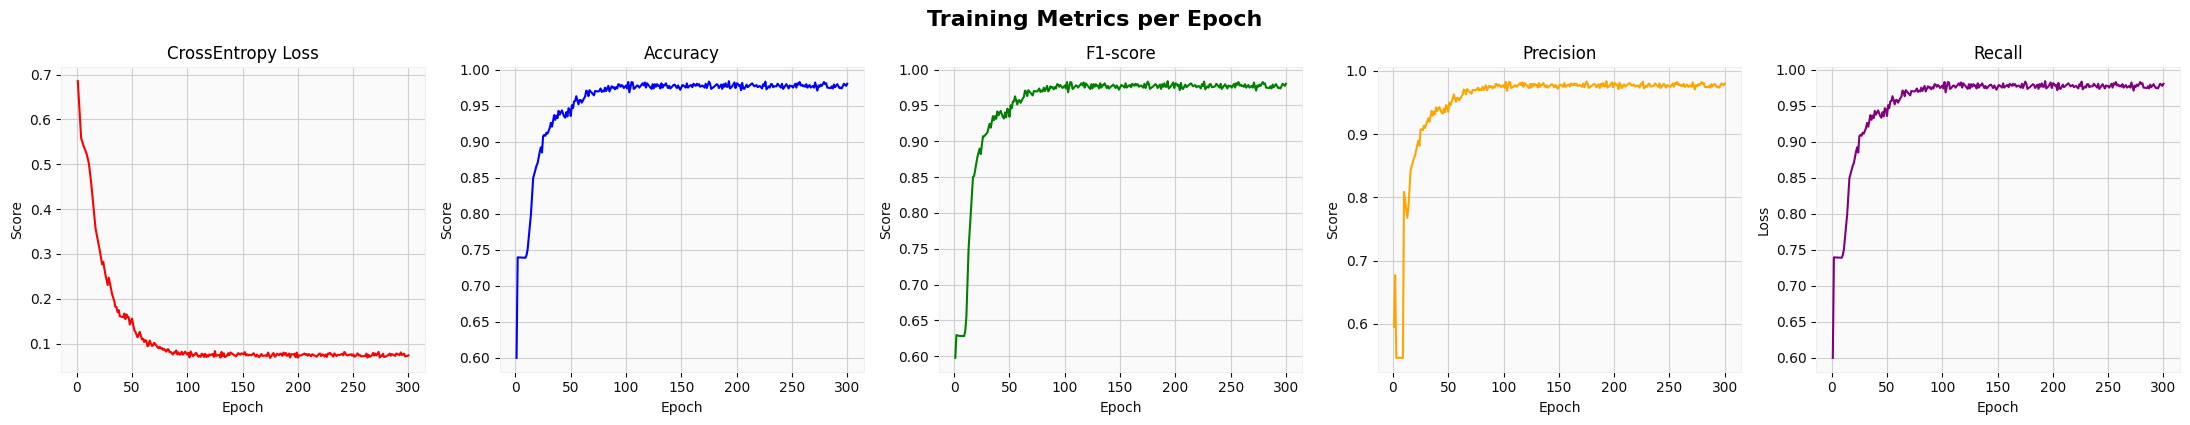

Plotting for label 0


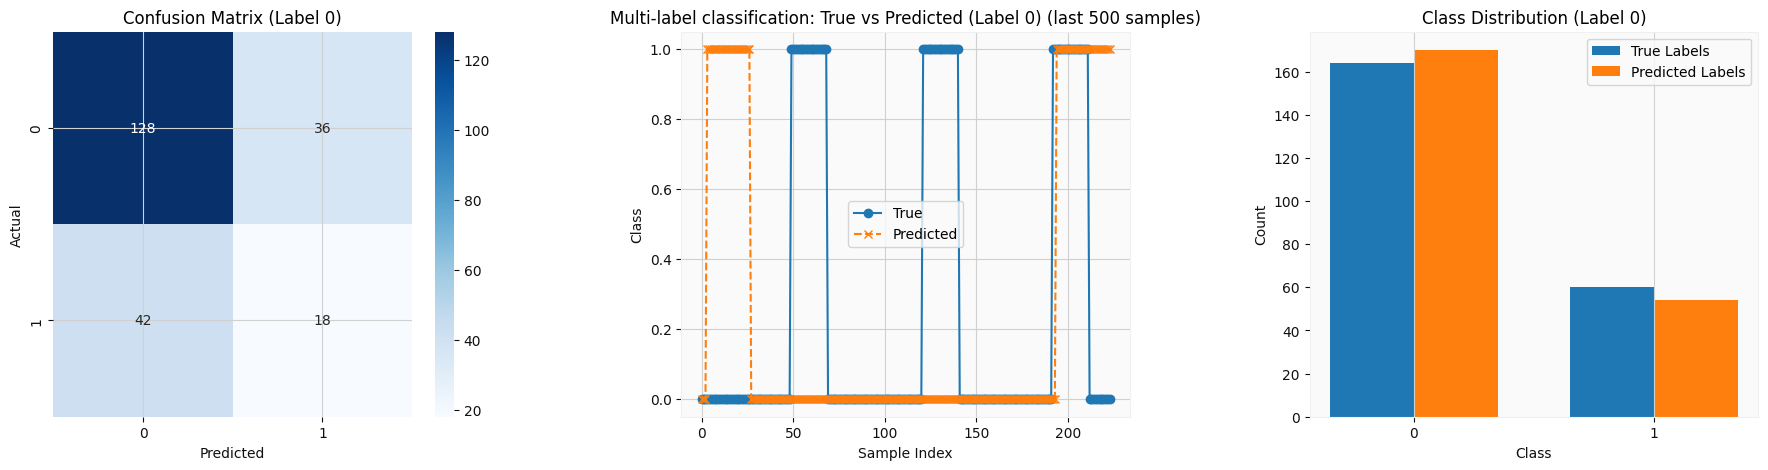

Plotting for label 1


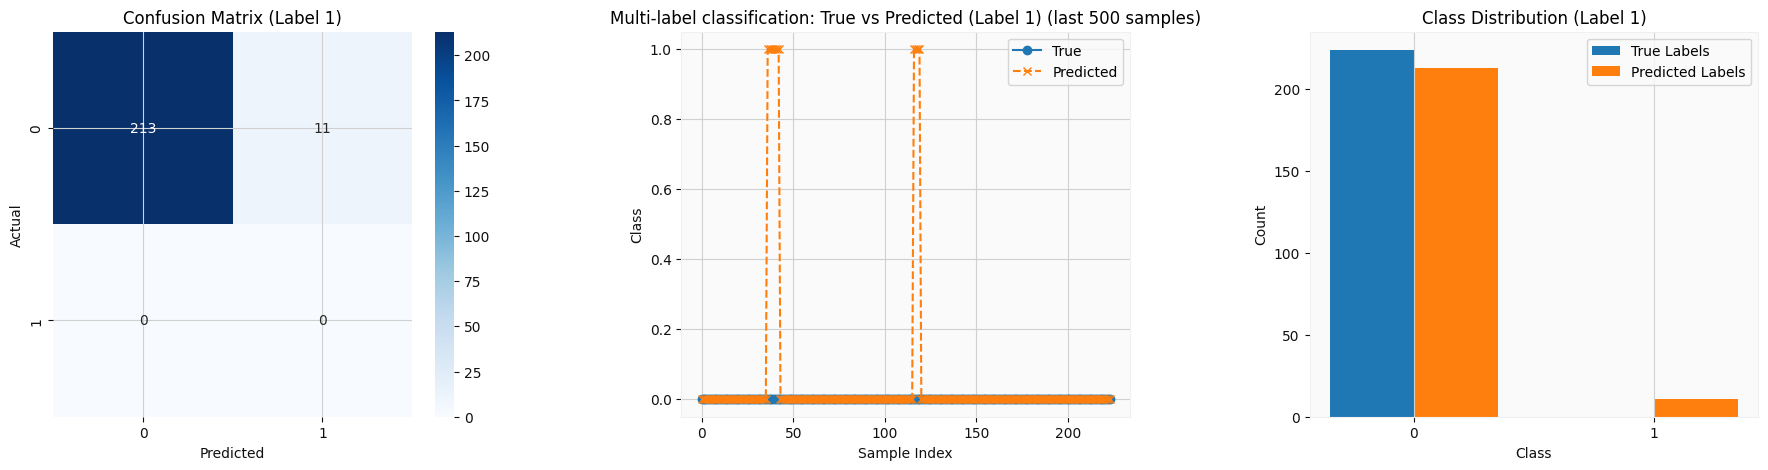

Plotting for label 2


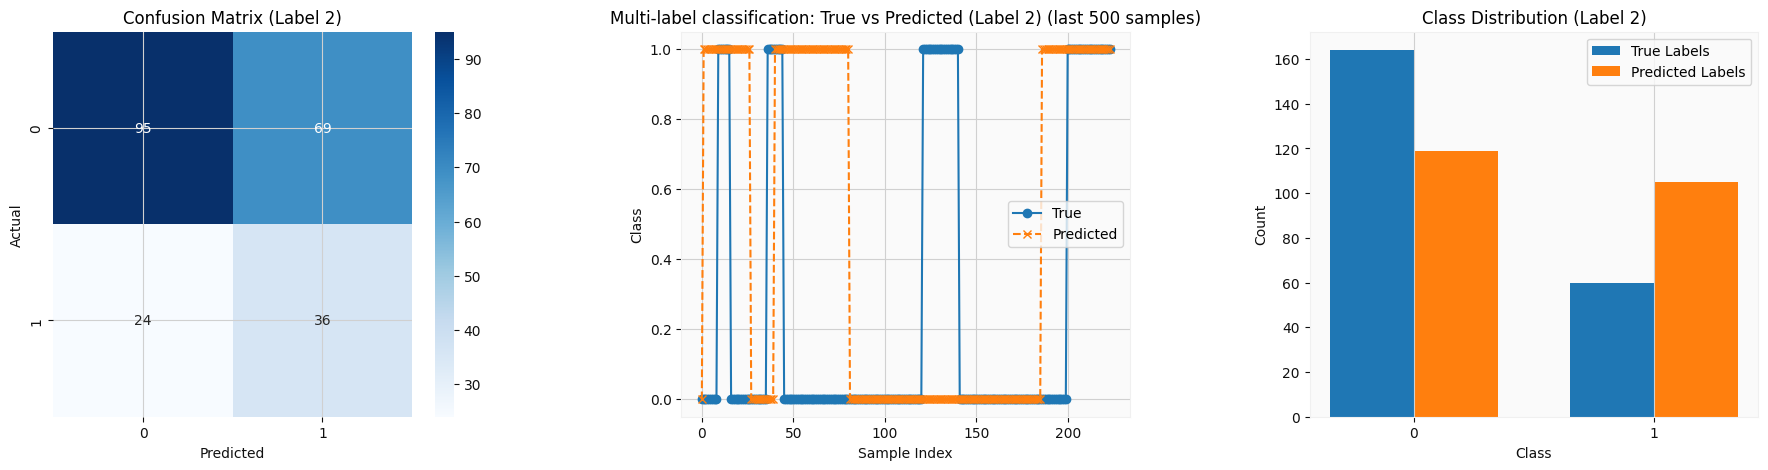

Plotting for label 3


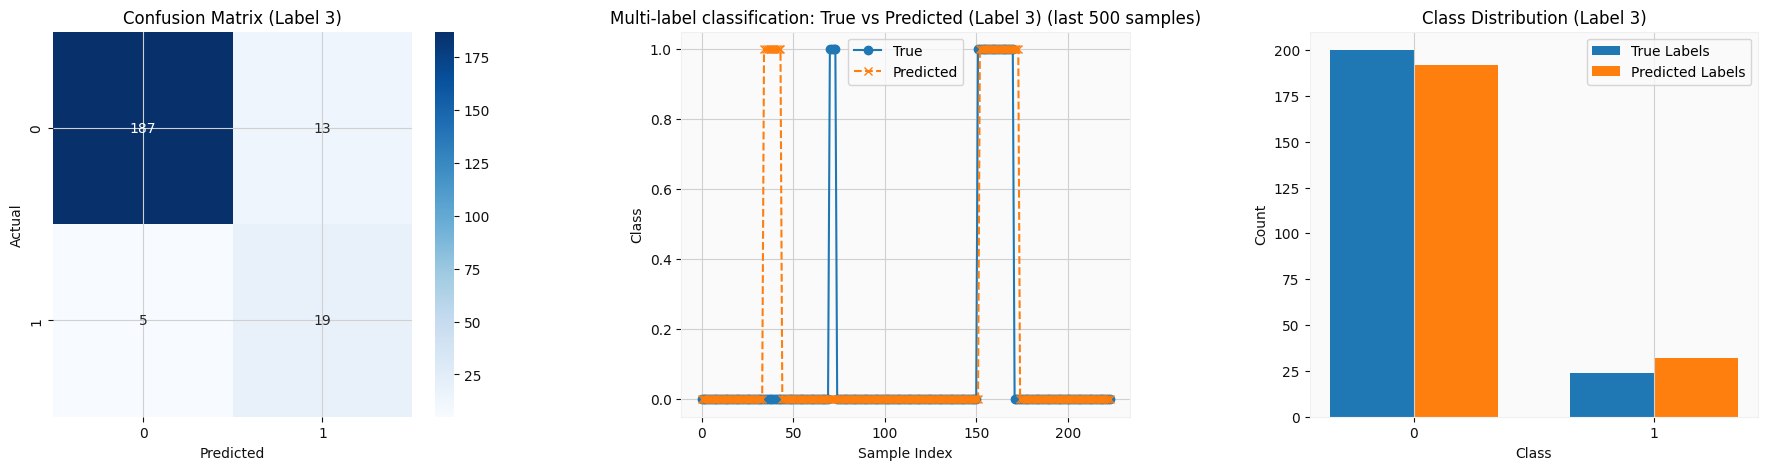

In [ ]:
# Step : Clean memory and delete old model (if it exists)
reset_training_state(model)  # model doit déjà exister

# Step : Recreate model + optimizer
model, optimizer, scheduler = create_model_and_optimizer(feature_dim, hidden_dim, output_dim, num_layers,num_epochs, n_labels, n_categories, dropout_p)

print("---------------------------------")

#-------------------------------------------------------------------------------
start_time = time.time()
#-------------------------------------------------------------------------------

for t in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    all_preds = []
    all_targets = []
# -------------------------------------------------------

    for x_batch, y_batch in train_loader:
        y_pred_split = model(x_batch)  # tuple/list of 3 tensors
        y_pred = torch.cat(y_pred_split, dim=1)  # → (batch_size, 3×7)

        loss = model.multi_task_loss(y_pred_split, y_batch)
        epoch_loss += loss.item()

        all_preds.append(y_pred.detach().cpu())  # OK maintenant
        all_targets.append(y_batch.detach().cpu())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    y_epoch_pred = torch.cat(all_preds, dim=0)
    y_epoch_true = torch.cat(all_targets, dim=0)
    model.update_metrics(y_epoch_pred, y_epoch_true)

    # ------------------ Validation phase ------------------

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            y_pred_split_val = model(x_val)
            loss_val = model.multi_task_loss(y_pred_split_val, y_val)
            val_loss += loss_val.item()

    val_loss /= len(val_dataset)
    scheduler.step(val_loss)

# -------------------------------------------------------

    if (t+1) % 10 == 0 or t == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {t+1} / Loss: {model.hist_criterion[t]:.4f} / Acc: {model.hist_acc[t]:.4f} / F1: {model.hist_f1[t]:.4f} / Precision: {model.hist_precision[t]:.4f} / Recall: {model.hist_recall[t]:.4f} / LR: {current_lr:.6f}")

# -------------------------------------------------------

print("---------------------------------")
print(f"Training time: {time.time() - start_time}")
print("--------------------------------")

#-------------------------------------------------------------------------------

chemin_enregistrement = "lstm_model.pth" # Nom du fichier où enregistrer le modèle
torch.save(model.state_dict(), chemin_enregistrement)
print(f"Modèle enregistré dans : {chemin_enregistrement}")
print("--------------------------------")

#-------------------------------------------------------------------------------

# Get Prediction
y_test_pred, y_test_pred_list = model.get_pred(x_test)

#-------------------------------------------------------------------------------

# Affichage des métriques
model.show_metrics(y_test,y_test_pred,y_test_pred_list)
model.visualize_classification_results(
    y_true=y_test,
    y_pred=y_test_pred,
    n_categories=n_categories,
    sequence_title="Multi-label classification: True vs Predicted",
    max_points=500
)
#-------------------------------------------------------------------------------